In [1]:
print("check Env")

check Env


In [3]:
# ===============================
# 1. Import Libraries
# ===============================

import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
# ===============================
# 2. Load Saved Train/Test Data
# ===============================

import joblib

X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3200, 12)
X_test: (800, 12)
y_train: (3200,)
y_test: (800,)


In [6]:
# ===============================
# 3. Define Suitable Models
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

Logistic Regression
Accuracy: 0.97625


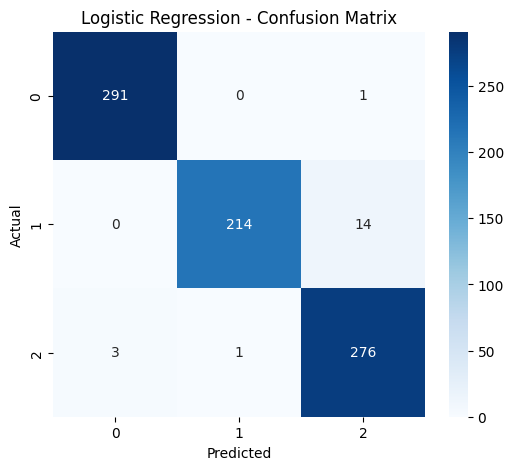


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       292
           1       1.00      0.94      0.97       228
           2       0.95      0.99      0.97       280

    accuracy                           0.98       800
   macro avg       0.98      0.97      0.98       800
weighted avg       0.98      0.98      0.98       800



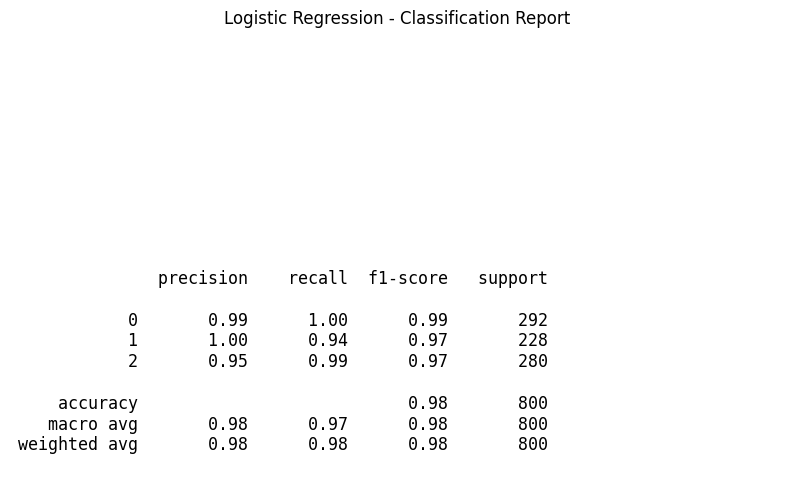

Decision Tree
Accuracy: 0.9025


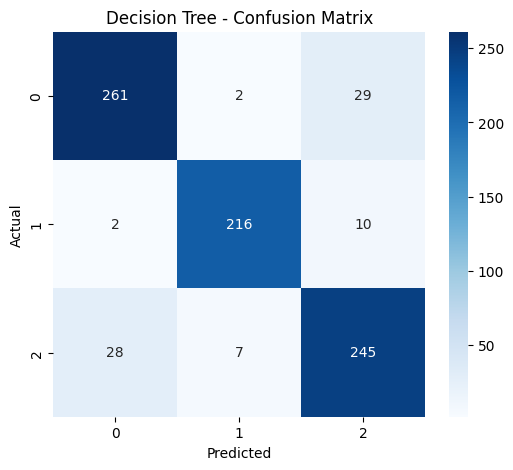


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       292
           1       0.96      0.95      0.95       228
           2       0.86      0.88      0.87       280

    accuracy                           0.90       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.90      0.90      0.90       800



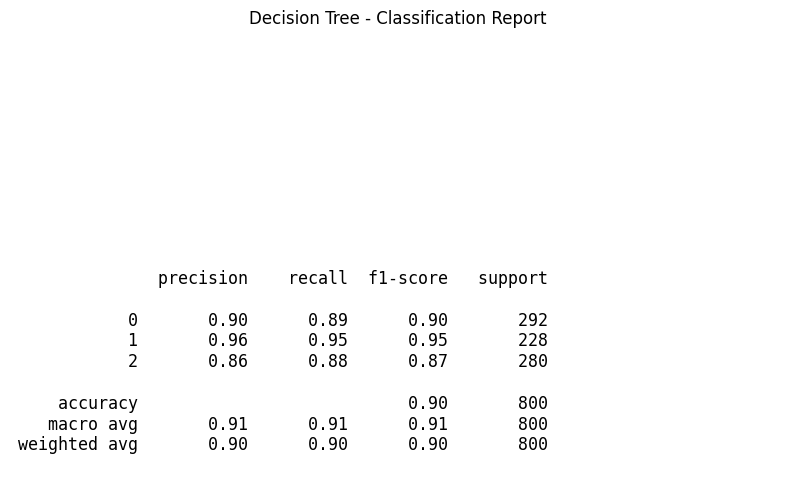

Random Forest
Accuracy: 0.92375


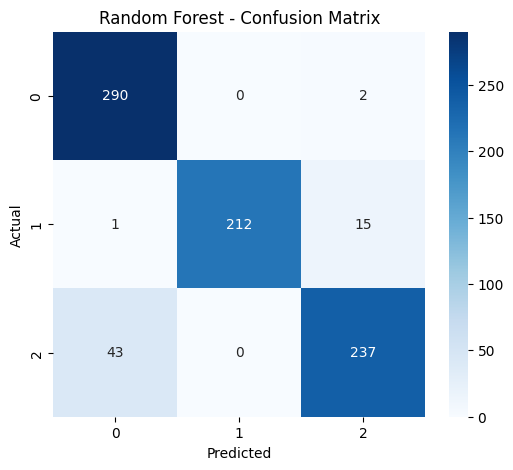


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       292
           1       1.00      0.93      0.96       228
           2       0.93      0.85      0.89       280

    accuracy                           0.92       800
   macro avg       0.93      0.92      0.93       800
weighted avg       0.93      0.92      0.92       800



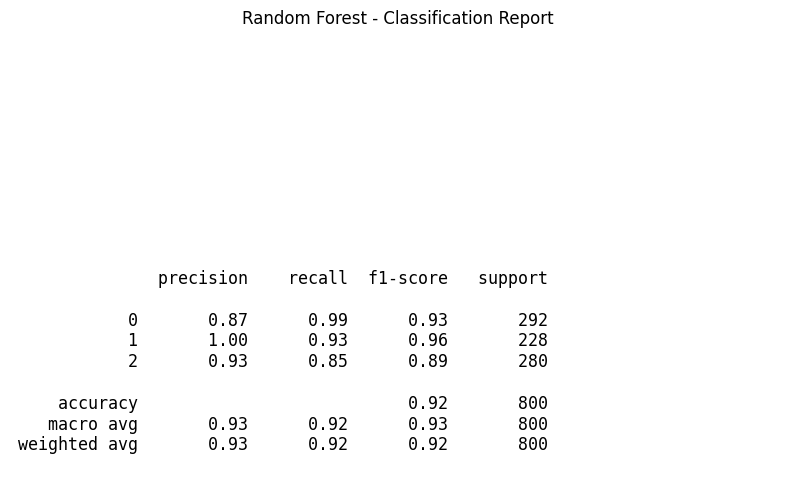

Gradient Boosting
Accuracy: 0.94


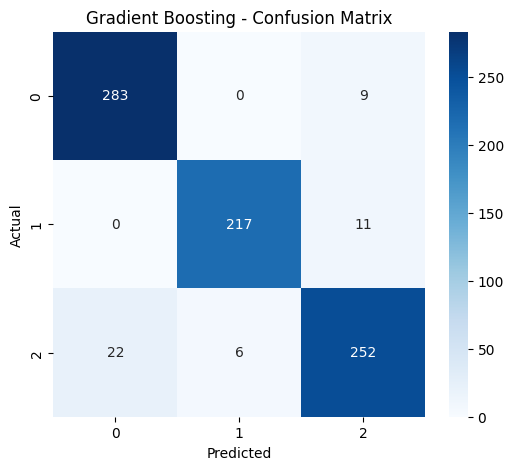


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       292
           1       0.97      0.95      0.96       228
           2       0.93      0.90      0.91       280

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



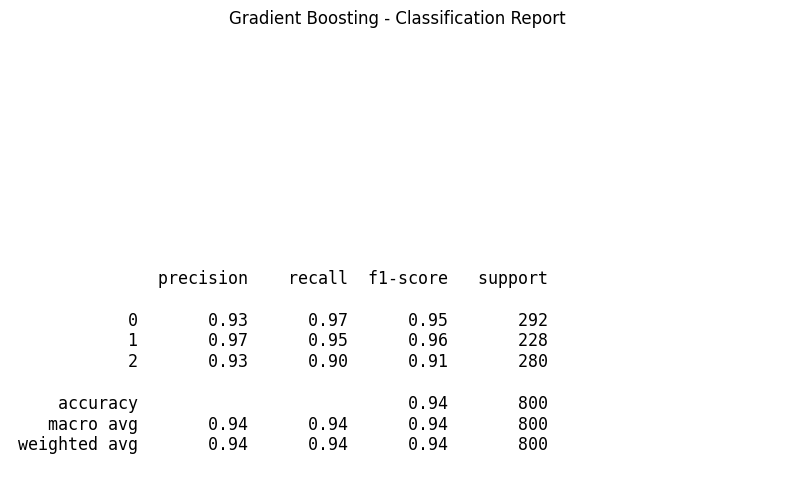

In [23]:
# ===============================
# 4. Train Models and Evaluate
# Save Reports as Images
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

results = {}

for model_name, model in models.items():

    print("=" * 60)
    print(model_name)

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy

    print("Accuracy:", accuracy)

    # ===============================
    # Confusion Matrix
    # ===============================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Save confusion matrix image
    plt.savefig(f"{model_name}_confusion_matrix.png")

    plt.show()

    # ===============================
    # Classification Report
    # ===============================

    report = classification_report(y_test, y_pred)

    print("\nClassification Report:")
    print(report)

    # Save report as image
    plt.figure(figsize=(10,6))
    plt.text(
        0.01,
        0.05,
        str(report),
        {'fontsize': 12},
        fontfamily='monospace'
    )

    plt.axis('off')

    plt.title(f'{model_name} - Classification Report')

    plt.savefig(f"{model_name}_classification_report.png")

    plt.show()

In [8]:
# ===============================
# 5. Compare Model Accuracies
# ===============================

results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.97625
3,Gradient Boosting,0.94000
2,Random Forest,0.92375
1,Decision Tree,0.90250


In [9]:
# ===============================
# 6. Select Best Model
# ===============================

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", results_df.iloc[0]["Accuracy"])

Best Model: Logistic Regression
Best Accuracy: 0.97625


In [10]:
# ===============================
# 7. Save Best Model
# ===============================

joblib.dump(best_model, "best_risk_prediction_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


In [20]:
# ===============================
# 8. Load Saved Model and Test
# ===============================

loaded_model = joblib.load("best_risk_prediction_model.pkl")

# Take first 5 samples
sample_prediction = loaded_model.predict(X_test[3:8])

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[1 2 2 2 2]


In [21]:
print("Actual Labels:")
print(y_test[3:8])

Actual Labels:
3930    1
2948    2
3615    2
1643    2
3283    2
Name: risk_status, dtype: int64


In [22]:
# ===============================
# 9. Save Model Evaluation Summary
# ===============================

results_df.to_csv("model_accuracy_results.csv", index=False)

print("Model accuracy results saved.")

Model accuracy results saved.
